# Histogram

In [3]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

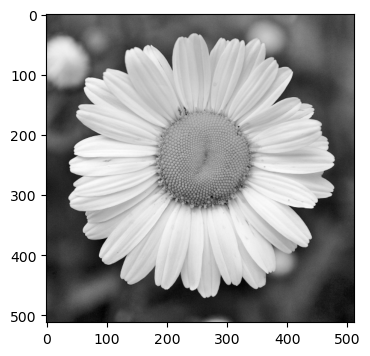

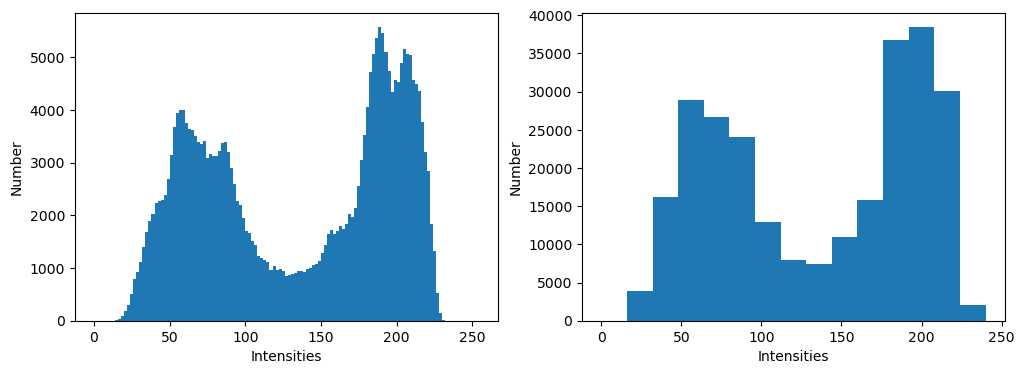

In [6]:
# Load the image
img = io.imread("../../src/figs/daisy.png", as_gray=True) * 255

# Display the image
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.imshow(img, cmap="gray")
plt.show()

# Prepare the figure for the histograms
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Plot the first histogram
axs[0].hist(
    img.ravel(),           # The image must be flattened to use function hist
    bins=range(0,256,2)    # Define 128 bins (of width 2) between 0 and 255
)
axs[0].set_xlabel("Intensities")
axs[0].set_ylabel("Number")

# Plot the second histogram
axs[1].hist(
    img.ravel(),           # The image must be flattened to use function hist
    bins=range(0,256,16)   # Define 16 bins (of width 16) between 0 and 255
)
axs[1].set_xlabel("Intensities")
axs[1].set_ylabel("Number")

# Show the figure
plt.savefig("daisy-histo.svg", transparent=True, bbox_inches="tight")
plt.show()

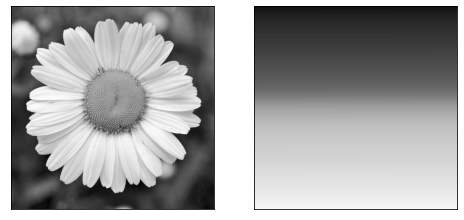

In [2]:
# Charge l'image
img = io.imread("../_static/figs/daisy.png", as_gray=True) * 255

# Réordonnement des pixels pour avoir une nouvelle image avec le même histogramme
imgs = np.sort(img.ravel())
imgs = np.reshape(imgs, img.shape)

# Affichage
fig = plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.xticks([])
plt.yticks([])
plt.subplot(1,2,2)
plt.imshow(imgs, cmap="gray")
plt.xticks([])
plt.yticks([])

plt.savefig("daisy-sorted.svg", transparent=True, bbox_inches="tight")

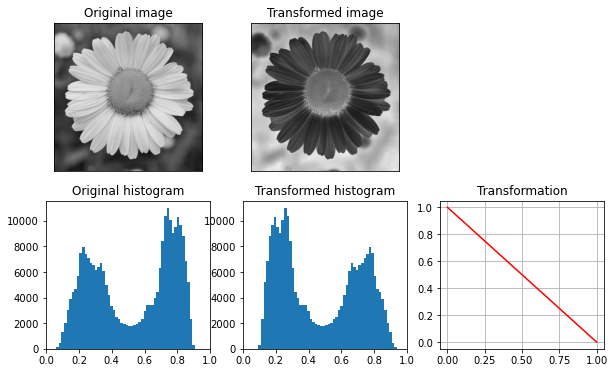

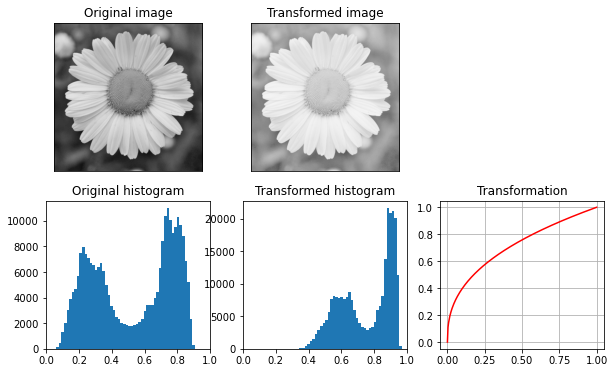

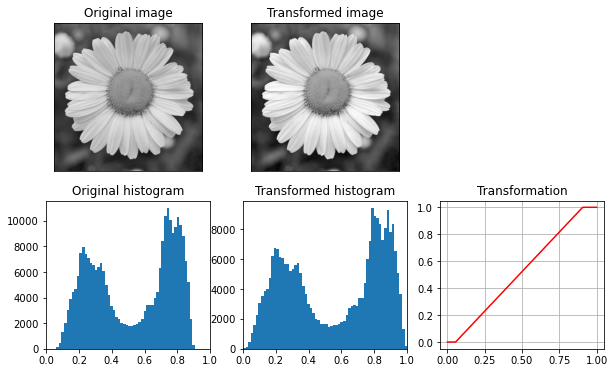

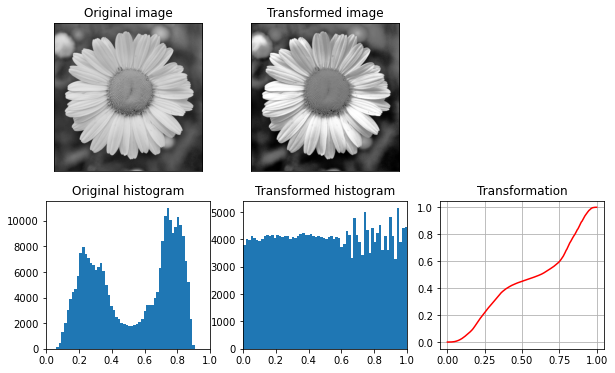

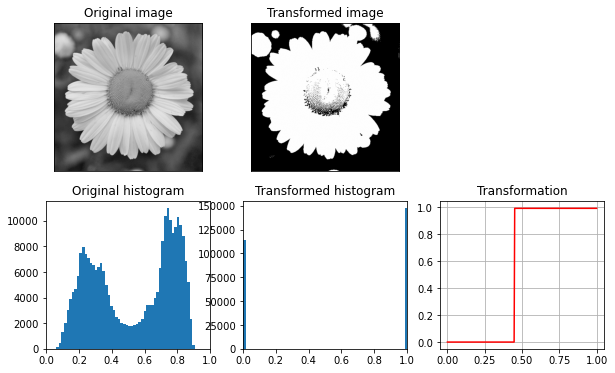

In [3]:
from skimage.exposure import equalize_hist, cumulative_distribution

# Charge l'image
img = io.imread("../_static/figs/daisy.png", as_gray=True) * 255
img = img / 255

transforms = ["negative", "gamma", "spreading", "equalization", "thresholding"]

x = np.linspace(0, 1, 256)

for t in transforms:

    if t == "negative":
        new = 1 - img
        transform = 1 - x
        
    if t == "gamma":
        gamma = 0.4;
        new = img**gamma
        transform = x**gamma
        
    if t == "spreading":
        transform = (x-img.min()) / (img.max()-img.min())
        transform = np.where(transform<0, 0, transform)
        transform = np.where(transform>1, 1, transform)
        new = (img-img.min()) / (img.max()-img.min())
        
    if t == "equalization":
        new = equalize_hist(img)
        transform = cumulative_distribution(img, 256)[0]
        
    if t == "thresholding":
        threshold = .45
        new = (img>threshold)*127/128
        transform = np.where(x>threshold, 127/128, 0)
    
    fig = plt.figure(figsize=(10,6))
    
    plt.subplot(2,3,1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.xticks([])
    plt.yticks([])
    plt.title("Original image")
    
    plt.subplot(2,3,2)
    plt.imshow(new, cmap="gray", vmin=0, vmax=1)
    plt.xticks([])
    plt.yticks([])
    plt.title("Transformed image")
    
    plt.subplot(2,3,4)
    plt.hist(img.ravel(), bins=np.linspace(0,1,64+1))
    plt.xlim((0, 1))
    plt.title("Original histogram")
    
    plt.subplot(2,3,5)
    plt.hist(new.ravel(), bins=np.linspace(0,1,64+1))
    plt.xlim((0, 1))
    plt.title("Transformed histogram")
    
    plt.subplot(2,3,6)
    plt.plot(x, transform, 'r')
    plt.xlim((-.05, 1.05))
    plt.ylim((-.05, 1.05))
    plt.grid()
    plt.title("Transformation")
    
    plt.savefig(f"{t}.svg", transparent=True, bbox_inches="tight")